In [19]:
%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import kwant
import numpy as np
from scipy import linalg as la
from koala import plotting as pl
from koala.lattice import Lattice
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function
from alter_morph.lattice_utilities import alter_lattice_maker, add_contacts
from alter_morph.mean_field import hartree_fock
from alter_morph.kwant_utilities import Amorphous

from tqdm import tqdm

# plotting
import matplotlib
import matplotlib.pyplot as plt

import koala.graph_utils

<Axes: >

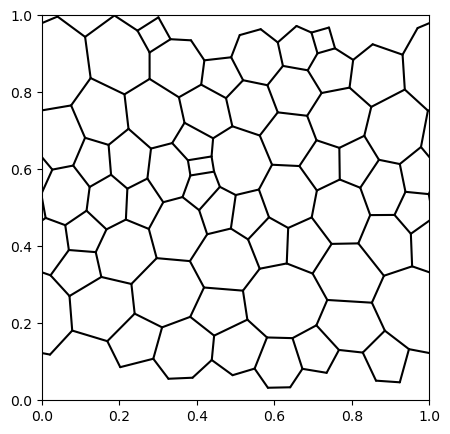

In [21]:
# create lattice
system_length = 12
seeds = 10
lattice_type = "voronoi"
n_fock_steps = 200


# set parameters, scan different values of J
t1 = 1  # orbital parallel neighbor hopping
t2 = 0.5  # orbital perpendicular neighbor hopping
J = 0.6  # Interaction strength
U = 0.6
filling = 0.9  # filling of the lattice
theta_values = np.linspace(0, np.pi, 100, endpoint=False)

lattice = alter_lattice_maker(system_length, lattice_type)
lattice = koala.graph_utils.cut_boundaries(lattice, [False, True])
lattice = koala.graph_utils.remove_trailing_edges(lattice)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
pl.plot_edges(lattice, ax=ax)

In [ ]:
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

last_m = np.full(lattice.n_vertices, 1)  # initial magnetization
last_n = np.full(lattice.n_vertices, filling * 4)  # initial density

cond_up = []
cond_down = []
ms = []
doss = []
spectrals = []
energy = []

for theta_offset in tqdm(theta_values):

    initial_parameters = {
        "t1": t1,
        "t2": t2,
        "J": J,
        "filling": filling,
        "U": U,
        "initial_m": last_m,
        "initial_n": last_n,
        "theta_offset": theta_offset,
    }
    m_values, n_values = hartree_fock(
        lattice,
        initial_parameters,
        n_fock_steps,
        tol_mdiff=1e-5,
        mixing_proportion=0.2,
        verbose=False,
        adjust_learning_rate=True,
    )
    last_m = m_values[-1]
    last_n = n_values[-1]

    hamiltonian = alt_hamiltonian(
        lattice,
        t1,
        t2,
        J,
        U,
        m_values[-1],
        n_values[-1],
        theta_offset,
        add_energy_shift=True,
    )
    energies, states = la.eigh(hamiltonian)
    fermi_energy = np.mean(
        energies[int(filling * len(energies)) - 1 : int(filling * len(energies)) + 1]
    )
    ground_state_energy = np.sum(energies[: int(filling * len(energies))])

    lead_onsite = np.mean(
        [
            hamiltonian[i * 4 : (i + 1) * 4, i * 4 : (i + 1) * 4]
            for i in range(lattice.n_vertices)
        ],
        axis=0,
    )
    lead_coupling = -np.eye(4)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice,
        k_lattice,
        k_system,
        contact_vertices,
        lead_onsite,
        lead_coupling,
        np.diag([-1, -1, 1, 1]),
    )

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f, energy=fermi_energy)
    g = np.array(
        [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
    )

    broadening = 5e-2
    norm_lorenzian = (1 / np.pi) * (
        broadening / ((energies - fermi_energy) ** 2 + broadening**2)
    )
    dos = np.mean(norm_lorenzian)

    # spectral function
    spectral = [
        spectral_function(
            lattice,
            energies,
            states,
            fermi_energy,
            local_operator=np.eye(4)[i],
            eta=broadening,
            n_k=50,
        )
        for i in range(4)
    ]

    cond_up.append(g[0, 0])
    cond_down.append(g[1, 1])
    ms.append(m_values[-1])
    doss.append(dos)
    spectrals.append(spectral)
    energy.append(ground_state_energy)

  4%|▍         | 4/100 [00:07<02:47,  1.74s/it]

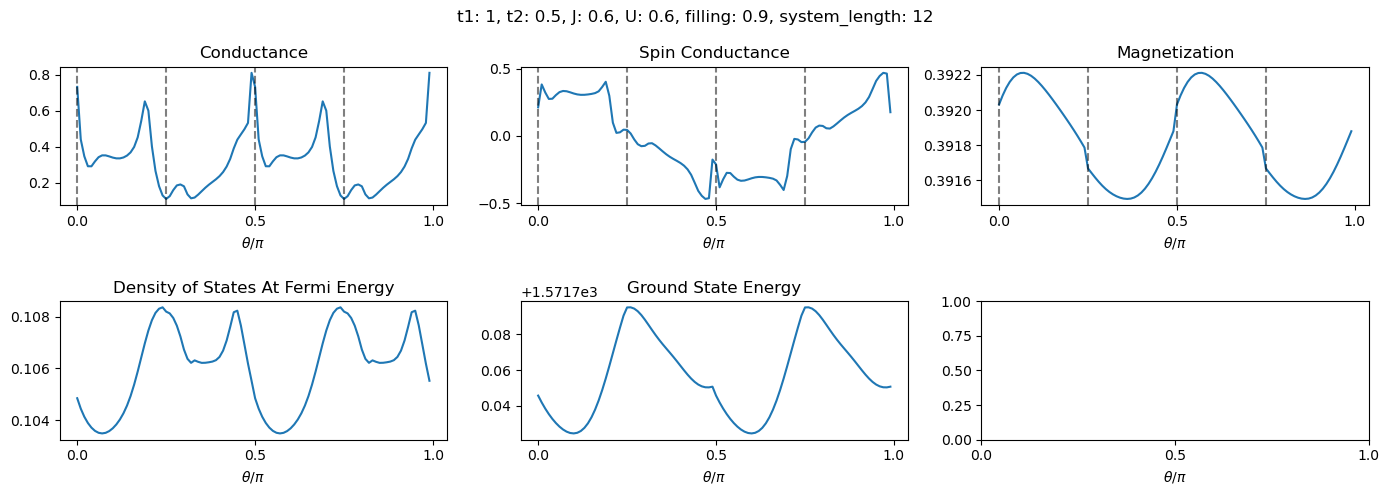

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(14, 5))
ax = ax.flatten()

ax[0].plot(theta_values / np.pi, cond_up)
ax[0].set_title("Conductance")
ax[1].plot(theta_values / np.pi, cond_down)
ax[1].set_title("Spin Conductance")
ax[2].plot(theta_values / np.pi, np.mean(ms, axis=1))
ax[2].set_title("Magnetization")
ax[3].plot(theta_values / np.pi, doss)
ax[3].set_title("Density of States At Fermi Energy")
ax[4].plot(theta_values / np.pi, energy)
ax[4].set_title("Ground State Energy")

# set x axis to be in pi units
for a in ax:
    a.set_xlabel(r"$\theta/\pi$")
    # a.set_xlim([0, 1])
    a.set_xticks([0, 0.5, 1])

for a in range(4):
    ax[0].axvline(a / 4, color="black", linestyle="--", alpha=0.5)
    ax[1].axvline(a / 4, color="black", linestyle="--", alpha=0.5)
    ax[2].axvline(a / 4, color="black", linestyle="--", alpha=0.5)

# figure title
fig.suptitle(
    f"t1: {t1}, t2: {t2}, J: {J}, U: {U}, filling: {filling}, system_length: {system_length}"
)


plt.tight_layout()